In [1]:
# Import libraries
import polars as pl
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import matplotlib.pyplot as plt

# Configuration
dataset_path = '/content/drive/MyDrive/dmeyf2025/datos/'
dataset_file = 'competencia_01.csv'


# Seed for reproducibility
from src.config import *

seed = SEMILLA

train_months = [202101, 202102, 202103]

base_path = ''
dataset_path = 'data/'
modelos_path = 'models/'
db_path = 'db/'
dataset_file = 'competencia_01.csv'

# FASE 1

In [2]:
# Load the dataset with Polars
print("Loading dataset...")
data = pl.read_csv(dataset_path + dataset_file)

print(f"Total rows: {data.height}")
print(f"Total columns: {data.width}")
print(f"\nFirst few rows:")
print(data.head())

Loading dataset...
Total rows: 978439
Total columns: 155

First few rows:
shape: (5, 155)
┌───────────┬──────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ numero_de ┆ foto_mes ┆ active_qu ┆ cliente_v ┆ … ┆ Visa_ccon ┆ Visa_cade ┆ Visa_mpag ┆ clase_ter │
│ _cliente  ┆ ---      ┆ arter     ┆ ip        ┆   ┆ sumos     ┆ lantosefe ┆ ominimo   ┆ naria     │
│ ---       ┆ i64      ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ctivo     ┆ ---       ┆ ---       │
│ i64       ┆          ┆ i64       ┆ i64       ┆   ┆ i64       ┆ ---       ┆ f64       ┆ str       │
│           ┆          ┆           ┆           ┆   ┆           ┆ i64       ┆           ┆           │
╞═══════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 249221323 ┆ 202101   ┆ 1         ┆ 0         ┆ … ┆ 6         ┆ 0         ┆ 9559.95   ┆ CONTINUA  │
│ 249221323 ┆ 202102   ┆ 1         ┆ 0         ┆ … ┆ 8         ┆ 0         ┆ 7413.36   ┆ CONTINUA  │
│

In [3]:
# Filter training data - only the 4 months we need
print("Filtering training months...")
train_data = data.filter(pl.col('foto_mes').is_in(train_months))

print(f"Training data rows: {train_data.height}")
print(f"Months in training data: {sorted(train_data['foto_mes'].unique().to_list())}")

Filtering training months...
Training data rows: 486791
Months in training data: [202101, 202102, 202103]


In [4]:
# Create binary target variable
# 0 = CONTINUA
# 1 = BAJA+1 OR BAJA+2

print("\nCreating binary target variable...")
train_data = train_data.with_columns([
    pl.when(pl.col('clase_ternaria').is_in(['BAJA+1', 'BAJA+2']))
      .then(1)
      .otherwise(0)
      .alias('clase_binaria')
])

# Check the distribution
print("\nTarget distribution:")
print(train_data['clase_binaria'].value_counts().sort('clase_binaria'))
print("\nOriginal class distribution:")
print(train_data['clase_ternaria'].value_counts())


Creating binary target variable...

Target distribution:
shape: (2, 2)
┌───────────────┬────────┐
│ clase_binaria ┆ count  │
│ ---           ┆ ---    │
│ i32           ┆ u32    │
╞═══════════════╪════════╡
│ 0             ┆ 481507 │
│ 1             ┆ 5284   │
└───────────────┴────────┘

Original class distribution:
shape: (3, 2)
┌────────────────┬────────┐
│ clase_ternaria ┆ count  │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ BAJA+1         ┆ 2480   │
│ BAJA+2         ┆ 2804   │
│ CONTINUA       ┆ 481507 │
└────────────────┴────────┘


In [5]:
# Verify our data looks correct
print("\nData shape:", train_data.shape)
print("\nColumns (first 10):", train_data.columns[:10])
print("\nClass balance:")
class_counts = train_data['clase_binaria'].value_counts().sort('clase_binaria')
total = train_data.height
print(class_counts.with_columns([
    (pl.col('count') / total * 100).alias('percentage')
]))


Data shape: (486791, 156)

Columns (first 10): ['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones']

Class balance:
shape: (2, 3)
┌───────────────┬────────┬────────────┐
│ clase_binaria ┆ count  ┆ percentage │
│ ---           ┆ ---    ┆ ---        │
│ i32           ┆ u32    ┆ f64        │
╞═══════════════╪════════╪════════════╡
│ 0             ┆ 481507 ┆ 98.914524  │
│ 1             ┆ 5284   ┆ 1.085476   │
└───────────────┴────────┴────────────┘


# FASE 2 - FEAT ENG

In [6]:
# First, let's identify numeric columns (exclude identifiers and target)
print("Identifying numeric columns...")

# Columns to exclude from lag creation
exclude_cols = ['numero_de_cliente', 'foto_mes', 'clase_ternaria', 'clase_binaria']

# Get numeric columns
numeric_cols = [
    col for col in train_data.columns 
    if train_data[col].dtype in [pl.Int64, pl.Int32, pl.Float64, pl.Float32]
    and col not in exclude_cols
]

print(f"Number of numeric columns for lags: {len(numeric_cols)}")
print(f"First 10 numeric columns: {numeric_cols[:10]}")

Identifying numeric columns...
Number of numeric columns for lags: 150
First 10 numeric columns: ['active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones', 'mactivos_margen', 'mpasivos_margen']


In [7]:
# CRITICAL: Sort by customer and month for proper lag calculation
print("\nSorting data by customer and month...")
train_data = train_data.sort(['numero_de_cliente', 'foto_mes'])

print("Data sorted successfully")
print(train_data.select(['numero_de_cliente', 'foto_mes', 'clase_ternaria']).head(10))


Sorting data by customer and month...
Data sorted successfully
shape: (10, 3)
┌───────────────────┬──────────┬────────────────┐
│ numero_de_cliente ┆ foto_mes ┆ clase_ternaria │
│ ---               ┆ ---      ┆ ---            │
│ i64               ┆ i64      ┆ str            │
╞═══════════════════╪══════════╪════════════════╡
│ 249221323         ┆ 202101   ┆ CONTINUA       │
│ 249221323         ┆ 202102   ┆ CONTINUA       │
│ 249221323         ┆ 202103   ┆ CONTINUA       │
│ 249227600         ┆ 202101   ┆ CONTINUA       │
│ 249227600         ┆ 202102   ┆ CONTINUA       │
│ 249227600         ┆ 202103   ┆ CONTINUA       │
│ 249234235         ┆ 202101   ┆ CONTINUA       │
│ 249234235         ┆ 202102   ┆ CONTINUA       │
│ 249234235         ┆ 202103   ┆ CONTINUA       │
│ 249244449         ┆ 202101   ┆ CONTINUA       │
└───────────────────┴──────────┴────────────────┘


In [8]:
print("\nCreating lag features...")

# Create lag_1 and lag_2 for each numeric column
lag_expressions = []

for col in numeric_cols:
    # Lag 1: previous month value
    lag_expressions.append(
        pl.col(col).shift(1).over('numero_de_cliente').alias(f'{col}_lag1')
    )
    
    # Lag 2: two months ago value
    lag_expressions.append(
        pl.col(col).shift(2).over('numero_de_cliente').alias(f'{col}_lag2')
    )

# Apply all lag transformations at once
train_data = train_data.with_columns(lag_expressions)

print(f"Created {len(lag_expressions)} lag features")
print(f"New shape: {train_data.shape}")


Creating lag features...
Created 300 lag features
New shape: (486791, 456)


In [9]:
print("\nCreating delta-lag features...")

# Create delta_lag_1 and delta_lag_2 for each numeric column
delta_expressions = []

for col in numeric_cols:
    # Delta lag 1: current - lag_1 (change from last month)
    delta_expressions.append(
        (pl.col(col) - pl.col(f'{col}_lag1')).alias(f'{col}_delta1')
    )
    
    # Delta lag 2: lag_1 - lag_2 (change between previous two months)
    delta_expressions.append(
        (pl.col(f'{col}_lag1') - pl.col(f'{col}_lag2')).alias(f'{col}_delta2')
    )

# Apply all delta transformations at once
train_data = train_data.with_columns(delta_expressions)

print(f"Created {len(delta_expressions)} delta-lag features")
print(f"Final shape: {train_data.shape}")


Creating delta-lag features...
Created 300 delta-lag features
Final shape: (486791, 756)


In [10]:
print("\nHandling missing values from lag creation...")

# Count nulls before
null_counts_before = train_data.null_count()
print(f"Total nulls before cleanup: {null_counts_before.sum_horizontal()[0]}")

# Remove rows where we can't calculate lags properly
# This happens for customers' first appearances or first months
# We need at least 2 previous months for lag_2
train_data = train_data.filter(
    pl.col(f'{numeric_cols[0]}_lag2').is_not_null()
)

print(f"\nRows after removing incomplete lag data: {train_data.height}")
print(f"Remaining months: {sorted(train_data['foto_mes'].unique().to_list())}")


Handling missing values from lag creation...
Total nulls before cleanup: 160707584

Rows after removing incomplete lag data: 160080
Remaining months: [202103]


In [13]:
print("\nVerifying lag features with a sample customer...")

# Take one customer and show their data across months
sample_customer = train_data.filter(
    pl.col('numero_de_cliente') == train_data['numero_de_cliente'][125]
).select([
    'numero_de_cliente', 
    'foto_mes',
    numeric_cols[145],  # original feature
    f'{numeric_cols[0]}_lag1',
    f'{numeric_cols[0]}_lag2',
    f'{numeric_cols[0]}_delta1',
    f'{numeric_cols[0]}_delta2'
]).sort('foto_mes')

print(sample_customer)


Verifying lag features with a sample customer...
shape: (1, 7)
┌──────────────┬──────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┐
│ numero_de_cl ┆ foto_mes ┆ Visa_fechaal ┆ active_quart ┆ active_quart ┆ active_quar ┆ active_quar │
│ iente        ┆ ---      ┆ ta           ┆ er_lag1      ┆ er_lag2      ┆ ter_delta1  ┆ ter_delta2  │
│ ---          ┆ i64      ┆ ---          ┆ ---          ┆ ---          ┆ ---         ┆ ---         │
│ i64          ┆          ┆ i64          ┆ i64          ┆ i64          ┆ i64         ┆ i64         │
╞══════════════╪══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╡
│ 249797738    ┆ 202103   ┆ 8519         ┆ 1            ┆ 1            ┆ 0           ┆ 0           │
└──────────────┴──────────┴──────────────┴──────────────┴──────────────┴─────────────┴─────────────┘


In [12]:
# Final summary
print("\n" + "="*50)
print("FEATURE ENGINEERING SUMMARY")
print("="*50)
print(f"Original features: {len(numeric_cols)}")
print(f"Lag features created: {len(numeric_cols) * 2}")
print(f"Delta-lag features created: {len(numeric_cols) * 2}")
print(f"Total new features: {len(numeric_cols) * 4}")
print(f"Final total features: {train_data.width}")
print(f"Final rows: {train_data.height}")
print("\nTarget distribution after cleaning:")
print(train_data['clase_binaria'].value_counts().sort('clase_binaria'))


FEATURE ENGINEERING SUMMARY
Original features: 150
Lag features created: 300
Delta-lag features created: 300
Total new features: 600
Final total features: 756
Final rows: 160080

Target distribution after cleaning:
shape: (2, 2)
┌───────────────┬────────┐
│ clase_binaria ┆ count  │
│ ---           ┆ ---    │
│ i32           ┆ u32    │
╞═══════════════╪════════╡
│ 0             ┆ 158117 │
│ 1             ┆ 1963   │
└───────────────┴────────┘


# FASE 3 - MODEL

In [13]:
print("Preparing data for LightGBM...")

# Separate features from target and metadata
feature_cols = [
    col for col in train_data.columns 
    if col not in ['numero_de_cliente', 'foto_mes', 'clase_ternaria', 'clase_binaria']
]

print(f"Total features: {len(feature_cols)}")
print(f"Total samples: {train_data.height}")

Preparing data for LightGBM...
Total features: 752
Total samples: 320375


In [14]:
print("Converting data to memory-efficient format...")

# Convert Polars DataFrame to float32 (half the memory of float64)
X = train_data.select(feature_cols).cast(pl.Float32).to_numpy()
y = train_data.select('clase_binaria').to_numpy().ravel().astype(np.int32)

print(f"X shape: {X.shape}")
print(f"X dtype: {X.dtype}")
print(f"X memory: {X.nbytes / (1024**3):.2f} GB")
print(f"y shape: {y.shape}")
print(f"y dtype: {y.dtype}")

Converting data to memory-efficient format...
X shape: (320375, 752)
X dtype: float32
X memory: 0.90 GB
y shape: (320375,)
y dtype: int32


In [15]:
print("\nSetting up 5-Fold Stratified Cross Validation...")

# Use StratifiedKFold to maintain class balance in each fold
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f"Number of folds: {n_folds}")
print(f"Shuffle: True")
print(f"Random state: {seed}")


Setting up 5-Fold Stratified Cross Validation...
Number of folds: 5
Shuffle: True
Random state: 123479


In [16]:
# Verify fold distributions
print("\nVerifying fold distributions...")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    train_class_dist = np.bincount(y[train_idx])
    val_class_dist = np.bincount(y[val_idx])
    
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Train: {len(train_idx)} samples | Class 0: {train_class_dist[0]} | Class 1: {train_class_dist[1]}")
    print(f"  Val:   {len(val_idx)} samples | Class 0: {val_class_dist[0]} | Class 1: {val_class_dist[1]}")
    print(f"  Val class 1 %: {val_class_dist[1] / len(val_idx) * 100:.2f}%")


Verifying fold distributions...

Fold 1:
  Train: 256300 samples | Class 0: 253078 | Class 1: 3222
  Val:   64075 samples | Class 0: 63270 | Class 1: 805
  Val class 1 %: 1.26%

Fold 2:
  Train: 256300 samples | Class 0: 253078 | Class 1: 3222
  Val:   64075 samples | Class 0: 63270 | Class 1: 805
  Val class 1 %: 1.26%

Fold 3:
  Train: 256300 samples | Class 0: 253078 | Class 1: 3222
  Val:   64075 samples | Class 0: 63270 | Class 1: 805
  Val class 1 %: 1.26%

Fold 4:
  Train: 256300 samples | Class 0: 253079 | Class 1: 3221
  Val:   64075 samples | Class 0: 63269 | Class 1: 806
  Val class 1 %: 1.26%

Fold 5:
  Train: 256300 samples | Class 0: 253079 | Class 1: 3221
  Val:   64075 samples | Class 0: 63269 | Class 1: 806
  Val class 1 %: 1.26%


In [17]:
from sklearn.metrics import roc_auc_score

def evaluate_with_cv(params, X, y, n_folds=5, seed=42):
    """
    Evaluate LightGBM with given parameters using K-Fold CV
    Returns mean AUC across all folds
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    auc_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        # Split data
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Create LightGBM datasets
        train_dataset = lgb.Dataset(X_train_fold, label=y_train_fold)
        val_dataset = lgb.Dataset(X_val_fold, label=y_val_fold, reference=train_dataset)
        
        # Train model
        model = lgb.train(
            params,
            train_dataset,
            valid_sets=[val_dataset],
            callbacks=[lgb.log_evaluation(0)]  # Silent training
        )
        
        # Predict and calculate AUC
        y_pred = model.predict(X_val_fold)
        auc = roc_auc_score(y_val_fold, y_pred)
        auc_scores.append(auc)
    
    return np.mean(auc_scores), np.std(auc_scores), auc_scores

In [18]:
print("\nTesting with default LightGBM parameters...")

# Basic LightGBM parameters
default_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_iterations': 100,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'verbose': -1,
    'seed': seed
}

# Evaluate
mean_auc, std_auc, fold_aucs = evaluate_with_cv(default_params, X, y, n_folds=5, seed=seed)

print(f"\n{'='*50}")
print(f"Default Parameters CV Results:")
print(f"{'='*50}")
print(f"Mean AUC: {mean_auc:.6f}")
print(f"Std AUC:  {std_auc:.6f}")
print(f"\nIndividual fold AUCs:")
for i, auc in enumerate(fold_aucs):
    print(f"  Fold {i+1}: {auc:.6f}")


Testing with default LightGBM parameters...

Default Parameters CV Results:
Mean AUC: 0.923822
Std AUC:  0.005038

Individual fold AUCs:
  Fold 1: 0.917125
  Fold 2: 0.927075
  Fold 3: 0.918541
  Fold 4: 0.929842
  Fold 5: 0.926529


In [19]:
def objective(trial):
    """
    Optuna objective function to optimize LightGBM hyperparameters
    Following professor's specification
    """
    # Hyperparameters to optimize (as specified by professor)
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'seed': seed,
        
        # Parameters to optimize
        'num_iterations': trial.suggest_int('num_iterations', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'min_data_in_leaf': 3  # Fixed as professor specified
    }
    
    # Evaluate with 5-fold CV
    mean_auc, _, _ = evaluate_with_cv(params, X, y, n_folds=5, seed=seed)
    
    return mean_auc

print("\nOptuna objective function defined!")
print("Parameters to optimize:")
print("  - num_iterations")
print("  - learning_rate")
print("  - feature_fraction")
print("  - num_leaves")
print("  - min_data_in_leaf: FIXED at 3")


Optuna objective function defined!
Parameters to optimize:
  - num_iterations
  - learning_rate
  - feature_fraction
  - num_leaves
  - min_data_in_leaf: FIXED at 3


# FASE 4

In [34]:
print("Creating Optuna study for Bayesian Optimization...")


storage_name = "sqlite:///" + db_path + "optimization_lgbm_v_nueva.db"
study_name = "version_nueva"

# Create study to MAXIMIZE AUC
study = optuna.create_study(
    direction='maximize',
    storage=storage_name,
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=1,  # 20 random trials (non-intelligent)
        seed=seed
    )
)

print(f"Study created: {study.study_name}")
print(f"Direction: {study.direction}")
print(f"Sampler: TPE (Tree-structured Parzen Estimator)")
print(f"Random initialization trials: 20")
print(f"Intelligent trials: 30")
print(f"Total trials: 50")

[I 2025-10-07 00:48:33,979] A new study created in RDB with name: no-name-5657eeaf-39a8-42f4-88f0-194df691e5e1


Creating Optuna study for Bayesian Optimization...
Study created: no-name-5657eeaf-39a8-42f4-88f0-194df691e5e1
Direction: 2
Sampler: TPE (Tree-structured Parzen Estimator)
Random initialization trials: 20
Intelligent trials: 30
Total trials: 50


In [35]:
print("\n" + "="*60)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("="*60)
print("This will take some time... ~30-60 minutes depending on your machine")
print("Each trial runs 5-fold CV, so 50 trials = 250 model trainings!")
print()

# Run optimization
n_trials = 3  # 20 random + 30 intelligent

study.optimize(
    objective, 
    n_trials=n_trials,
    show_progress_bar=True
)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)


STARTING HYPERPARAMETER OPTIMIZATION
This will take some time... ~30-60 minutes depending on your machine
Each trial runs 5-fold CV, so 50 trials = 250 model trainings!



  0%|          | 0/3 [00:00<?, ?it/s]

[I 2025-10-07 00:51:17,829] Trial 0 finished with value: 0.9327723384351809 and parameters: {'num_iterations': 212, 'learning_rate': 0.04219287400464054, 'feature_fraction': 0.5683050717297156, 'num_leaves': 126}. Best is trial 0 with value: 0.9327723384351809.
[I 2025-10-07 00:53:31,905] Trial 1 finished with value: 0.9332174464332841 and parameters: {'num_iterations': 182, 'learning_rate': 0.0394646238241429, 'feature_fraction': 0.5414877234458423, 'num_leaves': 133}. Best is trial 1 with value: 0.9332174464332841.
[I 2025-10-07 00:54:20,226] Trial 2 finished with value: 0.922015549555816 and parameters: {'num_iterations': 52, 'learning_rate': 0.011526391660069371, 'feature_fraction': 0.4189485891633511, 'num_leaves': 200}. Best is trial 1 with value: 0.9332174464332841.

OPTIMIZATION COMPLETE!


In [36]:
print("\nBest Trial Results:")
print("="*60)

best_trial = study.best_trial

print(f"Best AUC: {best_trial.value:.6f}")
print(f"Trial number: {best_trial.number}")
print(f"\nBest Hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")


Best Trial Results:
Best AUC: 0.933217
Trial number: 1

Best Hyperparameters:
  num_iterations: 182
  learning_rate: 0.0394646238241429
  feature_fraction: 0.5414877234458423
  num_leaves: 133


In [37]:
print("\n" + "="*60)
print("COMPARISON WITH PROFESSOR'S RESULTS")
print("="*60)

professor_auc = 0.9467175
our_auc = best_trial.value

print(f"Professor's AUC:  {professor_auc:.6f}")
print(f"Our AUC:          {our_auc:.6f}")
print(f"Difference:       {our_auc - professor_auc:+.6f}")

if our_auc >= professor_auc:
    print("✅ We matched or exceeded the professor's result!")
else:
    print("📊 Close! Small differences are normal due to randomness")


COMPARISON WITH PROFESSOR'S RESULTS
Professor's AUC:  0.946717
Our AUC:          0.933217
Difference:       -0.013500
📊 Close! Small differences are normal due to randomness


## ANALIZAMOS OPTUNA

In [41]:
print("\nGenerating optimization visualizations...")

# Plot 1: Optimization History
plot_optimization_history(study)


Generating optimization visualizations...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'mode': 'markers',
              'name': 'Objective Value',
              'type': 'scatter',
              'x': [0, 1, 2],
              'y': [0.9327723384351809, 0.9332174464332841, 0.922015549555816]},
             {'mode': 'lines',
              'name': 'Best Value',
              'type': 'scatter',
              'x': [0, 1, 2],
              'y': [0.9327723384351809, 0.9332174464332841, 0.9332174464332841]},
             {'marker': {'color': '#cccccc'},
              'mode': 'markers',
              'name': 'Infeasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [],
              'y': []}],
    'layout': {'template': '...',
               'title': {'text': 'Optimization History Plot'},
               'xaxis': {'title': {'text': 'Trial'}},
               'yaxis': {'title': {'text': 'Objective Value'}}}
})

In [40]:
# Plot 2: Parameter Importance
plot_param_importances(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'cliponaxis': False,
              'hovertemplate': [learning_rate (FloatDistribution):
                                0.1427180466744471<extra></extra>, num_leaves
                                (IntDistribution):
                                0.2541832812851561<extra></extra>, num_iterations
                                (IntDistribution):
                                0.2699416144050646<extra></extra>, feature_fraction
                                (FloatDistribution):
                                0.3331570576353322<extra></extra>],
              'name': 'Objective Value',
              'orientation': 'h',
              'text': [0.14, 0.25, 0.27, 0.33],
              'textposition': 'outside',
              'type': 'bar',
              'x': [0.1427180466744471, 0.2541832812851561, 0.2699416144050646,
                    0.3331570576353322],
              'y': [learning_rate, num_leaves, num_iterations, feature_fraction]}],
    'layout': {'template': '...',
               'title': {'text': 'Hyperparameter Importances'},
               'xaxis': {'title': {'text': 'Hyperparameter Importance'}},
               'yaxis': {'title': {'text': 'Hyperparameter'}}}
})

In [42]:
# Plot 3: Parallel Coordinate Plot (shows parameter relationships)
from optuna.visualization import plot_parallel_coordinate

plot_parallel_coordinate(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'dimensions': [{'label': 'Objective Value',
                              'range': [0.922015549555816, 0.9332174464332841],
                              'values': [0.9327723384351809, 0.9332174464332841,
                                         0.922015549555816]},
                             {'label': 'feature_fraction',
                              'range': [0.4189485891633511, 0.5683050717297156],
                              'values': [0.5683050717297156, 0.5414877234458423,
                                         0.4189485891633511]},
                             {'label': 'learning_rate',
                              'range': [-1.9383066274306129, -1.3747608912607954],
                              'ticktext': [0.0115, 0.0422],
                              'tickvals': [-1.9383066274306129,
                                           -1.3747608912607954],
                              'values': [-1.3747608912607954, -1.4037920325235742,
                                         -1.9383066274306129]},
                             {'label': 'num_iterations', 'range': [52, 212], 'values': [212, 182, 52]},
                             {'label': 'num_leaves', 'range': [126, 200], 'values': [126, 133, 200]}],
              'labelangle': 30,
              'labelside': 'bottom',
              'line': {'color': [0.9327723384351809, 0.9332174464332841,
                                 0.922015549555816],
                       'colorbar': {'title': {'text': 'Objective Value'}},
                       'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                      'rgb(222,235,247)'], [0.25,
                                      'rgb(198,219,239)'], [0.375,
                                      'rgb(158,202,225)'], [0.5,
                                      'rgb(107,174,214)'], [0.625,
                                      'rgb(66,146,198)'], [0.75,
                                      'rgb(33,113,181)'], [0.875, 'rgb(8,81,156)'],
                                      [1.0, 'rgb(8,48,107)']],
                       'reversescale': False,
                       'showscale': True},
              'type': 'parcoords'}],
    'layout': {'template': '...', 'title': {'text': 'Parallel Coordinate Plot'}}
})

## ANALIZAMOS TOP 5 TRIALS

In [43]:
print("\n" + "="*60)
print("TOP 5 TRIALS")
print("="*60)

# Get top 5 trials by AUC
top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:1]

for i, trial in enumerate(top_trials):
    print(f"\nRank {i+1}:")
    print(f"  AUC: {trial.value:.6f}")
    print(f"  Trial #: {trial.number}")
    print(f"  Parameters:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")


TOP 5 TRIALS

Rank 1:
  AUC: 0.933217
  Trial #: 1
  Parameters:
    num_iterations: 182
    learning_rate: 0.0394646238241429
    feature_fraction: 0.5414877234458423
    num_leaves: 133


In [44]:
print("\n" + "="*60)
print("STATISTICAL SUMMARY OF ALL TRIALS")
print("="*60)

all_aucs = [trial.value for trial in study.trials]

print(f"Total trials completed: {len(all_aucs)}")
print(f"Best AUC:     {np.max(all_aucs):.6f}")
print(f"Worst AUC:    {np.min(all_aucs):.6f}")
print(f"Mean AUC:     {np.mean(all_aucs):.6f}")
print(f"Median AUC:   {np.median(all_aucs):.6f}")
print(f"Std Dev:      {np.std(all_aucs):.6f}")


STATISTICAL SUMMARY OF ALL TRIALS
Total trials completed: 3
Best AUC:     0.933217
Worst AUC:    0.922016
Mean AUC:     0.929335
Median AUC:   0.932772
Std Dev:      0.005179


In [45]:
print("\n" + "="*60)
print("RE-EVALUATING BEST MODEL WITH DETAILED FOLD RESULTS")
print("="*60)

# Get best parameters
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'seed': seed,
    'min_data_in_leaf': 3,
    **best_trial.params
}

# Re-evaluate to see individual fold performance
mean_auc, std_auc, fold_aucs = evaluate_with_cv(best_params, X, y, n_folds=5, seed=seed)

print(f"\nMean AUC: {mean_auc:.6f} ± {std_auc:.6f}")
print(f"\nIndividual Fold Results:")
for i, auc in enumerate(fold_aucs):
    print(f"  Fold {i+1}: {auc:.6f}")

print(f"\nConsistency Check:")
print(f"  Min fold AUC: {np.min(fold_aucs):.6f}")
print(f"  Max fold AUC: {np.max(fold_aucs):.6f}")
print(f"  Range: {np.max(fold_aucs) - np.min(fold_aucs):.6f}")


RE-EVALUATING BEST MODEL WITH DETAILED FOLD RESULTS

Mean AUC: 0.933217 ± 0.004494

Individual Fold Results:
  Fold 1: 0.926854
  Fold 2: 0.937776
  Fold 3: 0.929195
  Fold 4: 0.937940
  Fold 5: 0.934322

Consistency Check:
  Min fold AUC: 0.926854
  Max fold AUC: 0.937940
  Range: 0.011086


# FASE 5

In [46]:
print("="*60)
print("PHASE 5: FINAL MODEL TRAINING")
print("="*60)

# Extract best parameters from Optuna study
best_params = study.best_trial.params

# Complete parameter set for LightGBM
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'seed': seed,
    'min_data_in_leaf': 3,
    **best_params
}

print("\nBest Hyperparameters:")
print("-" * 60)
for key, value in best_params.items():
    print(f"  {key:20s}: {value}")
print("-" * 60)
print(f"\nBest CV AUC: {study.best_value:.6f}")

PHASE 5: FINAL MODEL TRAINING

Best Hyperparameters:
------------------------------------------------------------
  num_iterations      : 182
  learning_rate       : 0.0394646238241429
  feature_fraction    : 0.5414877234458423
  num_leaves          : 133
------------------------------------------------------------

Best CV AUC: 0.933217


In [47]:
print("\n" + "="*60)
print("TRAINING FINAL MODEL ON ALL TRAINING DATA")
print("="*60)

# Create LightGBM dataset with all training data
train_dataset = lgb.Dataset(X, label=y, free_raw_data=False)

print(f"\nTraining samples: {X.shape[0]:,}")
print(f"Features: {X.shape[1]:,}")
print(f"Class distribution:")
print(f"  Class 0 (CONTINUA): {np.sum(y==0):,} ({np.sum(y==0)/len(y)*100:.2f}%)")
print(f"  Class 1 (BAJA+1/2): {np.sum(y==1):,} ({np.sum(y==1)/len(y)*100:.2f}%)")

print("\nTraining final model...")
import time
start_time = time.time()

final_model = lgb.train(
    final_params,
    train_dataset,
    valid_sets=[train_dataset],
    callbacks=[lgb.log_evaluation(period=50)]  # Show progress every 50 iterations
)

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds")


TRAINING FINAL MODEL ON ALL TRAINING DATA

Training samples: 320,375
Features: 752
Class distribution:
  Class 0 (CONTINUA): 316,348 (98.74%)
  Class 1 (BAJA+1/2): 4,027 (1.26%)

Training final model...
[50]	training's auc: 0.989255
[100]	training's auc: 0.99896
[150]	training's auc: 0.999617

✓ Training completed in 34.00 seconds


In [49]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance
feature_importance = final_model.feature_importance(importance_type='gain')
feature_names = feature_cols

# Create DataFrame for easier analysis
importance_df = pl.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort('importance', descending=True)

print("\nTop 20 Most Important Features:")
print("-" * 60)
for row in importance_df.head(20).iter_rows(named=True):
    print(f"  {row['feature']:40s}: {row['importance']:10.0f}")


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
------------------------------------------------------------
  ctrx_quarter                            :      51194
  ctrx_quarter_lag1                       :      17243
  ctrx_quarter_lag2                       :      15239
  mprestamos_personales                   :      13923
  mcuentas_saldo                          :      11917
  mpayroll                                :      11114
  mpasivos_margen                         :      10002
  cpayroll_trx                            :       9938
  mcaja_ahorro                            :       6399
  Master_status                           :       5525
  mrentabilidad_annual_lag2               :       5242
  mtarjeta_visa_consumo                   :       3810
  Master_mlimitecompra                    :       3721
  mcuenta_corriente_lag2                  :       3605
  mactivos_margen                         :       3474
  cliente_edad                            :       33

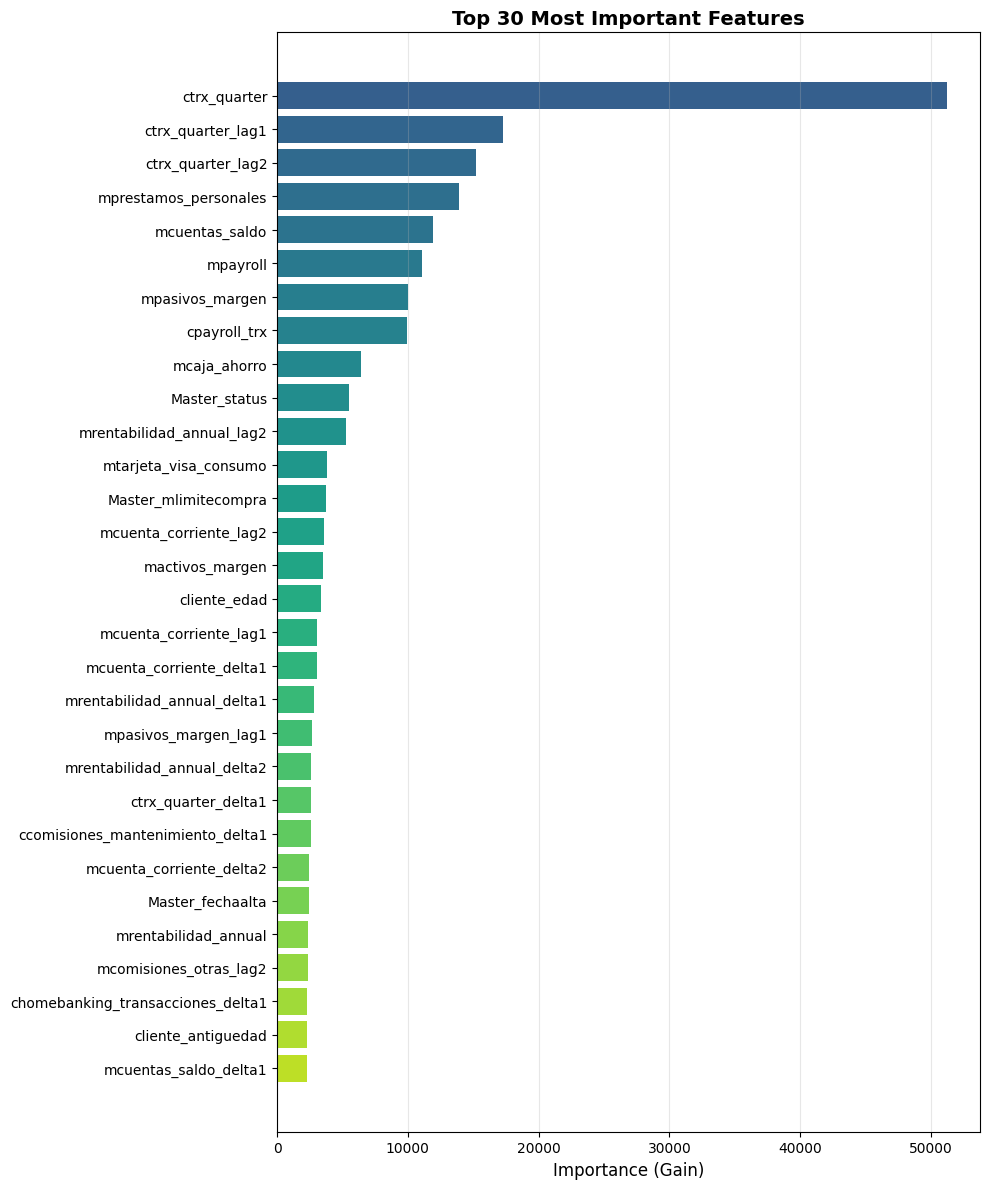


✓ Feature importance plot saved


In [52]:
# Visualize top features
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

top_n = 30
top_features = importance_df.head(top_n)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
bars = ax.barh(range(top_n), top_features['importance'].to_numpy(), color=colors)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].to_list())
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✓ Feature importance plot saved")

In [55]:
print("\n" + "="*60)
print("FEATURE TYPE ANALYSIS")
print("="*60)

# Categorize features (Polars syntax)
lag1_features = importance_df.filter(pl.col('feature').str.contains('_lag1'))
lag2_features = importance_df.filter(pl.col('feature').str.contains('_lag2'))
delta1_features = importance_df.filter(pl.col('feature').str.contains('_delta1'))
delta2_features = importance_df.filter(pl.col('feature').str.contains('_delta2'))
original_features = importance_df.filter(~pl.col('feature').str.contains('_lag|_delta'))

print(f"\nFeature Type Distribution:")
print(f"  Original features:  {len(original_features):4d} (avg importance: {original_features['importance'].mean():.0f})")
print(f"  Lag 1 features:     {len(lag1_features):4d} (avg importance: {lag1_features['importance'].mean():.0f})")
print(f"  Lag 2 features:     {len(lag2_features):4d} (avg importance: {lag2_features['importance'].mean():.0f})")
print(f"  Delta 1 features:   {len(delta1_features):4d} (avg importance: {delta1_features['importance'].mean():.0f})")
print(f"  Delta 2 features:   {len(delta2_features):4d} (avg importance: {delta2_features['importance'].mean():.0f})")

# Top feature from each category (Polars: use .row(0) for first row)
print(f"\nTop Feature by Category:")
print(f"  Original:  {original_features.row(0)[0]:40s} (importance: {original_features.row(0)[1]:.0f})")
print(f"  Lag 1:     {lag1_features.row(0)[0]:40s} (importance: {lag1_features.row(0)[1]:.0f})")
print(f"  Lag 2:     {lag2_features.row(0)[0]:40s} (importance: {lag2_features.row(0)[1]:.0f})")
print(f"  Delta 1:   {delta1_features.row(0)[0]:40s} (importance: {delta1_features.row(0)[1]:.0f})")
print(f"  Delta 2:   {delta2_features.row(0)[0]:40s} (importance: {delta2_features.row(0)[1]:.0f})")


FEATURE TYPE ANALYSIS

Feature Type Distribution:
  Original features:   152 (avg importance: 1333)
  Lag 1 features:      150 (avg importance: 489)
  Lag 2 features:      150 (avg importance: 481)
  Delta 1 features:    150 (avg importance: 453)
  Delta 2 features:    150 (avg importance: 314)

Top Feature by Category:
  Original:  ctrx_quarter                             (importance: 51194)
  Lag 1:     ctrx_quarter_lag1                        (importance: 17243)
  Lag 2:     ctrx_quarter_lag2                        (importance: 15239)
  Delta 1:   mcuenta_corriente_delta1                 (importance: 3035)
  Delta 2:   mrentabilidad_annual_delta2              (importance: 2618)


In [59]:
print("\n" + "="*60)
print("SAVING FINAL MODEL")
print("="*60)

model_path = modelos_path
model_filename = 'lgbm_final_comp1.txt'

# Save model
final_model.save_model(model_path + model_filename)

print(f"✓ Model saved to: {model_path + model_filename}")

# Also save as pickle for convenience
import joblib
joblib.dump(final_model, model_path + 'lgbm_final_comp1.pkl')
print(f"✓ Model also saved as: {model_path}lgbm_final_comp1.pkl")


SAVING FINAL MODEL
✓ Model saved to: models/lgbm_final_comp1.txt
✓ Model also saved as: models/lgbm_final_comp1.pkl


In [60]:
# Save feature names (important for prediction later)
import json

metadata = {
    'feature_names': feature_cols,
    'n_features': len(feature_cols),
    'best_params': final_params,
    'best_cv_auc': float(study.best_value),
    'training_samples': int(X.shape[0]),
    'training_months': train_months,
    'seed': seed,
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
}

with open(model_path + 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to: {model_path}model_metadata.json")

✓ Metadata saved to: models/model_metadata.json


In [61]:
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)

print(f"\nModel Performance:")
print(f"  Cross-Validation AUC: {study.best_value:.6f}")
print(f"  Training samples:     {X.shape[0]:,}")
print(f"  Total features:       {X.shape[1]:,}")
print(f"  Training time:        {training_time:.2f} seconds")

print(f"\nBest Hyperparameters:")
for key, value in best_params.items():
    print(f"  {key:20s}: {value}")

print(f"\nFeature Engineering:")
print(f"  Original features:    ~{len(original_features)}")
print(f"  Lag features:         {len(lag1_features) + len(lag2_features)}")
print(f"  Delta features:       {len(delta1_features) + len(delta2_features)}")

print(f"\nModel Files Saved:")
print(f"  {model_filename}")
print(f"  lgbm_final_comp1.pkl")
print(f"  model_metadata.json")
print(f"  feature_importance.png")

print("\n" + "="*60)
print("PHASE 5 COMPLETE! ✓")
print("="*60)


FINAL MODEL SUMMARY

Model Performance:
  Cross-Validation AUC: 0.933217
  Training samples:     320,375
  Total features:       752
  Training time:        34.00 seconds

Best Hyperparameters:
  num_iterations      : 182
  learning_rate       : 0.0394646238241429
  feature_fraction    : 0.5414877234458423
  num_leaves          : 133

Feature Engineering:
  Original features:    ~152
  Lag features:         300
  Delta features:       300

Model Files Saved:
  lgbm_final_comp1.txt
  lgbm_final_comp1.pkl
  model_metadata.json
  feature_importance.png

PHASE 5 COMPLETE! ✓


# FASE 6 - LOAD

In [16]:
# LOAD MODEL from model_path + model_filename
import joblib
final_model = joblib.load(modelos_path + 'lgbm_final_comp1.pkl')




# FASE 6

In [17]:
print("="*60)
print("PHASE 6: PREDICTION & SUBMISSION")
print("="*60)

# Test month - what we need to predict
test_month = 202106

print(f"\nLoading test data for {test_month}...")

# Load full dataset again (we need history for lags)
data_for_prediction = pl.read_csv(dataset_path + dataset_file)

print(f"Total data loaded: {data_for_prediction.height:,} rows")
print(f"Available months: {sorted(data_for_prediction['foto_mes'].unique().to_list())}")

PHASE 6: PREDICTION & SUBMISSION

Loading test data for 202106...
Total data loaded: 978,439 rows
Available months: [202101, 202102, 202103, 202104, 202105, 202106]


In [18]:
print("\n" + "="*60)
print("APPLYING FEATURE ENGINEERING TO TEST DATA")
print("="*60)

# We need months 202104, 202105, 202106 to calculate lags for 202106
required_months = [202104, 202105, 202106]

print(f"\nFiltering required months: {required_months}")
data_for_lags = data_for_prediction.filter(
    pl.col('foto_mes').is_in(required_months)
)

print(f"Data for lag calculation: {data_for_lags.height:,} rows")


APPLYING FEATURE ENGINEERING TO TEST DATA

Filtering required months: [202104, 202105, 202106]
Data for lag calculation: 491,648 rows


In [19]:
# Sort by customer and month (CRITICAL!)
print("\nSorting data for lag calculation...")
data_for_lags = data_for_lags.sort(['numero_de_cliente', 'foto_mes'])

print("✓ Data sorted")


Sorting data for lag calculation...
✓ Data sorted


In [20]:
# Apply same feature engineering as training
print("\nCreating lag features (order 1 and 2)...")

# Get same numeric columns as training
lag_expressions = []

for col in numeric_cols:
    # Lag 1: previous month value
    lag_expressions.append(
        pl.col(col).shift(1).over('numero_de_cliente').alias(f'{col}_lag1')
    )
    
    # Lag 2: two months ago value
    lag_expressions.append(
        pl.col(col).shift(2).over('numero_de_cliente').alias(f'{col}_lag2')
    )

data_for_lags = data_for_lags.with_columns(lag_expressions)
print(f"✓ Created {len(lag_expressions)} lag features")


Creating lag features (order 1 and 2)...
✓ Created 300 lag features


In [21]:
# Create delta-lag features
print("\nCreating delta-lag features...")

delta_expressions = []

for col in numeric_cols:
    # Delta lag 1: current - lag_1
    delta_expressions.append(
        (pl.col(col) - pl.col(f'{col}_lag1')).alias(f'{col}_delta1')
    )
    
    # Delta lag 2: lag_1 - lag_2
    delta_expressions.append(
        (pl.col(f'{col}_lag1') - pl.col(f'{col}_lag2')).alias(f'{col}_delta2')
    )

data_for_lags = data_for_lags.with_columns(delta_expressions)
print(f"✓ Created {len(delta_expressions)} delta-lag features")


Creating delta-lag features...
✓ Created 300 delta-lag features


In [26]:
# Filter only test month (202106) after creating lags
print(f"\nFiltering test month ({test_month})...")
test_data = data_for_lags.filter(pl.col('foto_mes') == test_month)

print(f"Test data rows: {test_data.height:,}")

# Check for nulls
null_check = test_data.select(pl.col(f'{numeric_cols[0]}_lag2').is_null().sum())
print(f"Rows with null lags: {null_check[0,0]}")

# Remove rows with null lags (customers without enough history)
#test_data = test_data.filter(pl.col(f'{numeric_cols[0]}_lag2').is_not_null())
#print(f"Test data after removing nulls: {test_data.height:,}")


Filtering test month (202106)...
Test data rows: 164,313
Rows with null lags: 2980


In [27]:
print("Preparing data for LightGBM...")

# Separate features from target and metadata
feature_cols = [
    col for col in train_data.columns 
    if col not in ['numero_de_cliente', 'foto_mes', 'clase_ternaria', 'clase_binaria']
]

Preparing data for LightGBM...


In [28]:
print("\n" + "="*60)
print("PREPARING FEATURES FOR PREDICTION")
print("="*60)

# Extract features in the SAME ORDER as training
X_test = test_data.select(feature_cols).cast(pl.Float32).to_numpy()

# Keep customer IDs for submission
customer_ids = test_data.select('numero_de_cliente').to_numpy().ravel()

print(f"\nTest data shape: {X_test.shape}")
print(f"Number of customers to predict: {len(customer_ids):,}")
print(f"Features match training: {X_test.shape[1] == len(feature_cols)}")


PREPARING FEATURES FOR PREDICTION

Test data shape: (164313, 752)
Number of customers to predict: 164,313
Features match training: True


In [30]:
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)



# Predict probabilities
y_pred_proba = final_model.predict(X_test)


print(f"\nPrediction statistics:")
print(f"  Min probability:  {y_pred_proba.min():.6f}")
print(f"  Max probability:  {y_pred_proba.max():.6f}")
print(f"  Mean probability: {y_pred_proba.mean():.6f}")
print(f"  Median probability: {np.median(y_pred_proba):.6f}")


MAKING PREDICTIONS

Prediction statistics:
  Min probability:  0.000000
  Max probability:  0.999915
  Mean probability: 0.008734
  Median probability: 0.000522


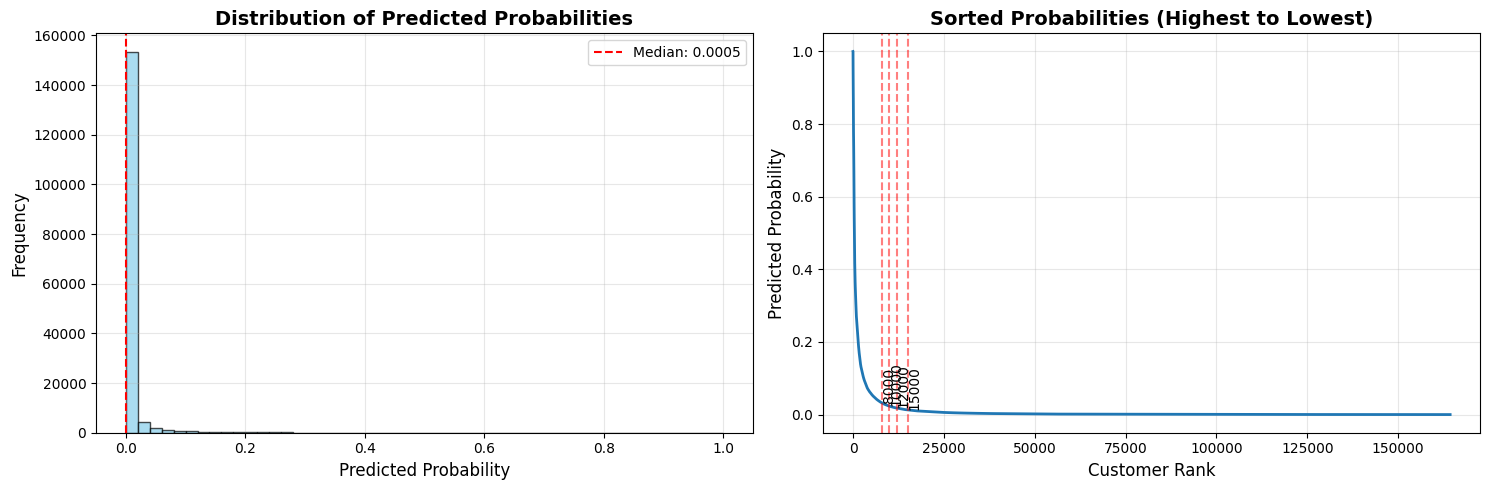


✓ Prediction distribution plot saved


In [34]:
# Visualize prediction distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of probabilities
ax1.hist(y_pred_proba, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel('Predicted Probability', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(np.median(y_pred_proba), color='r', linestyle='--', 
            label=f'Median: {np.median(y_pred_proba):.4f}')
ax1.legend()

# Cumulative distribution
sorted_proba = np.sort(y_pred_proba)[::-1]
ax2.plot(range(len(sorted_proba)), sorted_proba, linewidth=2)
ax2.set_xlabel('Customer Rank', fontsize=12)
ax2.set_ylabel('Predicted Probability', fontsize=12)
ax2.set_title('Sorted Probabilities (Highest to Lowest)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add reference lines for common cutoff points
cutoffs = [8000, 10000, 12000, 15000]
for cutoff in cutoffs:
    if cutoff < len(sorted_proba):
        ax2.axvline(cutoff, color='red', linestyle='--', alpha=0.5)
        ax2.text(cutoff, sorted_proba[cutoff], f'{cutoff}', rotation=90, va='bottom')

plt.tight_layout()
plt.show()

print("\n✓ Prediction distribution plot saved")

In [35]:
print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF STIMULI")
print("="*60)

# We don't have true labels for test set, so we'll use multiple submission strategies
# Based on professor's approach and common practice

# Strategy 1: Fixed numbers to try
submission_sizes = [8000, 9000, 10000, 11000, 12000, 13000]

print("\nWe'll create multiple submissions with different cutoffs:")
for size in submission_sizes:
    print(f"  - Top {size:,} customers")


DETERMINING OPTIMAL NUMBER OF STIMULI

We'll create multiple submissions with different cutoffs:
  - Top 8,000 customers
  - Top 9,000 customers
  - Top 10,000 customers
  - Top 11,000 customers
  - Top 12,000 customers
  - Top 13,000 customers


In [38]:
print("\n" + "="*60)
print("CREATING KAGGLE SUBMISSION FILES")
print("="*60)

submission_path = 'predict_v2/'

# Create submission directory if it doesn't exist
import os
os.makedirs(submission_path, exist_ok=True)

# Sort customers by probability (highest first)
sorted_indices = np.argsort(y_pred_proba)[::-1]
sorted_customer_ids = customer_ids[sorted_indices]
sorted_probabilities = y_pred_proba[sorted_indices]

# Create submissions for each size
for n_customers in submission_sizes:
    # Select top N customers
    selected_customers = sorted_customer_ids[:n_customers]
    
    # Create submission dataframe
    submission_df = pl.DataFrame({
        'numero_de_cliente': selected_customers,
        'Predicted': 1  # All selected customers get 1 (will receive stimulus)
    })
    
    # Save to CSV
    filename = f'submission_top_{n_customers}.csv'
    submission_df.write_csv(submission_path + filename)
    
    print(f"✓ Created: {filename}")
    print(f"    Customers: {len(selected_customers):,}")
    print(f"    Min probability: {sorted_probabilities[n_customers-1]:.6f}")
    print(f"    Max probability: {sorted_probabilities[0]:.6f}")
    print()


CREATING KAGGLE SUBMISSION FILES
✓ Created: submission_top_8000.csv
    Customers: 8,000
    Min probability: 0.031738
    Max probability: 0.999915

✓ Created: submission_top_9000.csv
    Customers: 9,000
    Min probability: 0.026955
    Max probability: 0.999915

✓ Created: submission_top_10000.csv
    Customers: 10,000
    Min probability: 0.023354
    Max probability: 0.999915

✓ Created: submission_top_11000.csv
    Customers: 11,000
    Min probability: 0.020312
    Max probability: 0.999915

✓ Created: submission_top_12000.csv
    Customers: 12,000
    Min probability: 0.017932
    Max probability: 0.999915

✓ Created: submission_top_13000.csv
    Customers: 13,000
    Min probability: 0.015899
    Max probability: 0.999915



In [42]:
print("\n" + "="*60)
print("SUBMISSION ANALYSIS")
print("="*60)

# Create detailed file with probabilities for reference
analysis_df = pl.DataFrame({
    'numero_de_cliente': sorted_customer_ids,
    'predicted_probability': sorted_probabilities,
    'rank': range(1, len(sorted_customer_ids) + 1)
})

# Add submission flags
for n in submission_sizes:
    analysis_df = analysis_df.with_columns(
        (pl.col('rank') <= n).cast(pl.Int32).alias(f'in_top_{n}')
    )

# Save analysis file
analysis_df.write_csv(submission_path + 'prediction_analysis.csv')
print(f"✓ Detailed analysis saved: prediction_analysis.csv")

# Show summary
print(f"\nPrediction Summary:")
print(f"  Total customers predicted: {len(customer_ids):,}")
print(f"  Probability range: [{y_pred_proba.min():.6f}, {y_pred_proba.max():.6f}]")
print(f"\nProbability thresholds for each submission:")
for n in submission_sizes:
    threshold = sorted_probabilities[n-1]
    print(f"  Top {n:5,}: probability >= {threshold:.6f}")


SUBMISSION ANALYSIS
✓ Detailed analysis saved: prediction_analysis.csv

Prediction Summary:
  Total customers predicted: 164,313
  Probability range: [0.000000, 0.999915]

Probability thresholds for each submission:
  Top 8,000: probability >= 0.031738
  Top 9,000: probability >= 0.026955
  Top 10,000: probability >= 0.023354
  Top 11,000: probability >= 0.020312
  Top 12,000: probability >= 0.017932
  Top 13,000: probability >= 0.015899


In [43]:
print("\n" + "="*60)
print("PROFESSOR'S GUIDANCE")
print("="*60)

print("\nFrom the professor's message:")
print("  'La ganancia de esa campaña virtual de 3 casos nos dará $740.000'")
print("  Typical optimal range: 8,000 - 13,000 customers")
print("\nOur submissions cover this range:")
for n in submission_sizes:
    print(f"  ✓ {n:,} customers")

print("\n" + "="*60)
print("RECOMMENDATION FOR FIRST SUBMISSION")
print("="*60)
print("\nStart with middle ground submissions:")
print("  1. submission_top_10000.csv  (safe, conservative)")
print("  2. submission_top_11000.csv  (balanced)")
print("  3. submission_top_12000.csv  (more aggressive)")
print("\nAfter seeing public leaderboard results, adjust accordingly.")


PROFESSOR'S GUIDANCE

From the professor's message:
  'La ganancia de esa campaña virtual de 3 casos nos dará $740.000'
  Typical optimal range: 8,000 - 13,000 customers

Our submissions cover this range:
  ✓ 8,000 customers
  ✓ 9,000 customers
  ✓ 10,000 customers
  ✓ 11,000 customers
  ✓ 12,000 customers
  ✓ 13,000 customers

RECOMMENDATION FOR FIRST SUBMISSION

Start with middle ground submissions:
  1. submission_top_10000.csv  (safe, conservative)
  2. submission_top_11000.csv  (balanced)
  3. submission_top_12000.csv  (more aggressive)

After seeing public leaderboard results, adjust accordingly.


In [44]:
print("\n" + "="*60)
print("PHASE 6 COMPLETE! ✓")
print("="*60)

print("\n📁 FILES CREATED:")
print(f"  Location: {submission_path}")
print(f"\n  Submission files ({len(submission_sizes)}):")
for n in submission_sizes:
    print(f"    - submission_top_{n}.csv")
print(f"\n  Analysis file:")
print(f"    - prediction_analysis.csv")
print(f"\n  Visualization:")
print(f"    - prediction_distribution.png")

print("\n📊 SUBMISSION STATISTICS:")
print(f"  Total predictions made: {len(customer_ids):,}")
print(f"  Submission range: {min(submission_sizes):,} - {max(submission_sizes):,} customers")
print(f"  Model CV AUC: {study.best_value:.6f}")

print("\n🎯 NEXT STEPS:")
print("  1. Go to Kaggle competition page")
print("  2. Upload submission_top_11000.csv (recommended starting point)")
print("  3. Check public leaderboard score")
print("  4. Adjust submission size based on results")
print("  5. Try other submission files")
print("\n  Remember: Don't overfit to public leaderboard!")
print("  Maximum 5 submissions per day to avoid 'Winner's Curse'")

print("\n" + "="*60)
print("🚀 READY FOR KAGGLE SUBMISSION!")
print("="*60)


PHASE 6 COMPLETE! ✓

📁 FILES CREATED:
  Location: predict_v2/

  Submission files (6):
    - submission_top_8000.csv
    - submission_top_9000.csv
    - submission_top_10000.csv
    - submission_top_11000.csv
    - submission_top_12000.csv
    - submission_top_13000.csv

  Analysis file:
    - prediction_analysis.csv

  Visualization:
    - prediction_distribution.png

📊 SUBMISSION STATISTICS:
  Total predictions made: 164,313
  Submission range: 8,000 - 13,000 customers


NameError: name 'study' is not defined